In [ ]:
import pandas as pd
import sqlite3

weather_data = {
    '札幌': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [-3.6, -3.1, 0.6, 7.1, 12.4, 16.7, 20.5, 22.3, 18.2, 11.8, 4.4, -1.2],
        '最高気温': [-0.9, -0.5, 4.1, 11.5, 17.3, 21.5, 24.9, 26.4, 22.6, 16.2, 8.4, 1.5],
        '最低気温': [-7.0, -6.6, -3.1, 2.9, 7.9, 12.7, 17.0, 19.1, 14.6, 7.9, 0.8, -4.1]
    },
    '仙台': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [1.6, 2.2, 5.2, 10.6, 15.5, 18.8, 22.4, 24.8, 21.0, 15.4, 9.7, 4.3],
        '最高気温': [5.4, 6.3, 9.8, 15.7, 20.8, 23.5, 26.3, 29.0, 25.2, 19.9, 14.3, 8.5],
        '最低気温': [-1.7, -1.2, 1.2, 6.0, 11.0, 15.2, 19.5, 21.6, 17.6, 11.6, 5.8, 0.7]
    },
    '東京': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [5.8, 7.0, 10.7, 15.4, 19.7, 22.4, 26.4, 28.4, 24.6, 18.7, 13.3, 8.3],
        '最高気温': [10.0, 11.9, 15.7, 20.7, 24.8, 26.9, 30.8, 33.1, 28.7, 22.9, 17.8, 12.5],
        '最低気温': [2.1, 2.9, 6.5, 11.0, 15.4, 18.8, 23.0, 24.7, 21.3, 15.3, 9.6, 4.8]
    },
    '大阪': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [6.0, 6.7, 10.7, 15.8, 20.4, 23.5, 27.4, 29.1, 25.2, 19.1, 13.4, 8.1],
        '最高気温': [9.9, 10.9, 15.3, 21.0, 25.7, 28.3, 32.0, 34.1, 29.8, 23.8, 18.0, 12.3],
        '最低気温': [2.8, 3.3, 6.8, 11.3, 16.0, 19.8, 23.9, 25.3, 21.6, 15.3, 9.6, 4.7]
    },
    '福岡': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [7.0, 8.3, 11.9, 16.4, 20.3, 23.3, 27.2, 28.4, 24.8, 19.5, 14.4, 9.3],
        '最高気温': [10.8, 12.5, 16.3, 21.3, 25.0, 27.3, 31.0, 32.5, 28.7, 23.9, 18.7, 13.4],
        '最低気温': [3.8, 4.8, 8.1, 12.2, 16.3, 20.2, 24.3, 25.3, 21.8, 15.9, 10.8, 5.9]
    },
    '那覇': {
        '月': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
        '平均気温': [17.3, 17.8, 19.4, 21.7, 24.6, 27.4, 29.0, 28.7, 27.6, 25.2, 22.1, 18.9],
        '最高気温': [19.8, 20.4, 22.2, 24.7, 27.6, 30.2, 31.9, 31.7, 30.5, 28.1, 24.9, 21.5],
        '最低気温': [15.2, 15.7, 17.1, 19.3, 22.2, 25.2, 26.8, 26.4, 25.3, 23.0, 19.8, 16.7]
    }
}

# データフレームに変換
all_data = []
for city, data in weather_data.items():
    for i in range(len(data['月'])):
        all_data.append({
            '都市': city,
            '月': data['月'][i],
            '平均気温': data['平均気温'][i],
            '最高気温': data['最高気温'][i],
            '最低気温': data['最低気温'][i]
        })

df = pd.DataFrame(all_data)


print("気象データ分析")


# データ概要の表示
print("\nデータ概要")
print(f"総データ件数:{len(df)}件")
print(f"\n都市別データ件数:")
print(df['都市'].value_counts().sort_index())

print("\n各都市の年平均気温")
avg_by_city = df.groupby('都市')['平均気温'].mean().round(1).sort_values(ascending=False)
for city, temp in avg_by_city.items():
    print(f"{city}: {temp}℃")

# SQLiteに保存
conn = sqlite3.connect('weather_tourism.db')
df.to_sql('temperature_data', conn, if_exists='replace', index=False)
print("\nデータベースに保存:weather_tourism.db")
conn.close()

# CSVに保存
df.to_csv('weather_data_2024.csv', index=False, encoding='utf-8-sig')
print("CSVファイルに保存:weather_data_2024.csv")

# データサンプル表示
print("\nデータサンプル")
print(df.head(15))

気象データ分析

データ概要
総データ件数:72件

都市別データ件数:
都市
仙台    12
大阪    12
札幌    12
東京    12
福岡    12
那覇    12
Name: count, dtype: int64

各都市の年平均気温
那覇: 23.3℃
福岡: 17.6℃
大阪: 17.1℃
東京: 16.7℃
仙台: 12.6℃
札幌: 8.8℃

データベースに保存:weather_tourism.db
CSVファイルに保存: weather_data_2024.csv

データサンプル
    都市   月  平均気温  最高気温  最低気温
0   札幌   1  -3.6  -0.9  -7.0
1   札幌   2  -3.1  -0.5  -6.6
2   札幌   3   0.6   4.1  -3.1
3   札幌   4   7.1  11.5   2.9
4   札幌   5  12.4  17.3   7.9
5   札幌   6  16.7  21.5  12.7
6   札幌   7  20.5  24.9  17.0
7   札幌   8  22.3  26.4  19.1
8   札幌   9  18.2  22.6  14.6
9   札幌  10  11.8  16.2   7.9
10  札幌  11   4.4   8.4   0.8
11  札幌  12  -1.2   1.5  -4.1
12  仙台   1   1.6   5.4  -1.7
13  仙台   2   2.2   6.3  -1.2
14  仙台   3   5.2   9.8   1.2


気象データに基づく6都市の旅行適性分析


(0.0, 105.0)

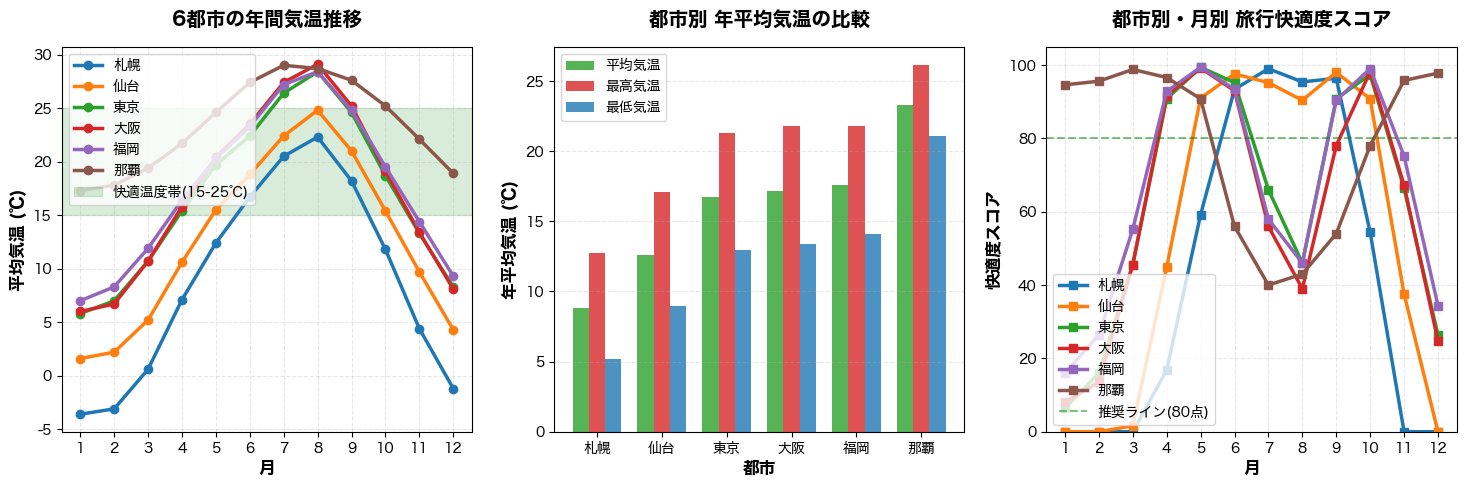

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

# 日本語フォント設定
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'MS Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# データベースから読み込み
conn = sqlite3.connect('weather_tourism.db')
df = pd.read_sql_query("SELECT * FROM temperature_data", conn)
conn.close()

print("気象データに基づく6都市の旅行適性分析")

conn = sqlite3.connect('weather_tourism.db')
df = pd.read_sql_query("SELECT * FROM temperature_data", conn)
conn.close()

# 快適度スコアの算出
def calculate_comfort_score(temp):
    ideal_temp = 20
    if pd.isna(temp):
        return 0
    if 15 <= temp <= 25:
        return 100 - abs(temp - ideal_temp) * 2
    elif temp < 15:
        return max(0, 80 - (15 - temp) * 8)
    else:
        return max(0, 80 - (temp - 25) * 10)

df['快適度スコア'] = df['平均気温'].apply(calculate_comfort_score)
df['気温変動幅'] = df['最高気温'] - df['最低気温']



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# グラフ1:年間気温推移
ax1 = axes[0]
cities = df['都市'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for city, color in zip(cities, colors):
    city_data = df[df['都市'] == city].sort_values('月')
    ax1.plot(city_data['月'], city_data['平均気温'], marker='o', 
             label=city, linewidth=2.5, markersize=6, color=color)

ax1.axhspan(15, 25, alpha=0.15, color='green', label='快適温度帯(15-25℃)')
ax1.set_xlabel('月', fontsize=12, fontweight='bold')
ax1.set_ylabel('平均気温 (℃)', fontsize=12, fontweight='bold')
ax1.set_title('6都市の年間気温推移', fontsize=14, fontweight='bold', pad=15)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, 13))

# グラフ2:最高・最低気温の比較
ax2 = axes[1]
x_pos = np.arange(len(cities))
width = 0.25

avg_temps = [df[df['都市']==city]['平均気温'].mean() for city in cities]
max_temps = [df[df['都市']==city]['最高気温'].mean() for city in cities]
min_temps = [df[df['都市']==city]['最低気温'].mean() for city in cities]

ax2.bar(x_pos - width, avg_temps, width, label='平均気温', color='#2ca02c', alpha=0.8)
ax2.bar(x_pos, max_temps, width, label='最高気温', color='#d62728', alpha=0.8)
ax2.bar(x_pos + width, min_temps, width, label='最低気温', color='#1f77b4', alpha=0.8)

ax2.set_xlabel('都市', fontsize=12, fontweight='bold')
ax2.set_ylabel('年平均気温 (℃)', fontsize=12, fontweight='bold')
ax2.set_title('都市別 年平均気温の比較', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(cities, rotation=0)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# グラフ3:快適度スコアの月別推移
ax3 = axes[2]

for city, color in zip(cities, colors):
    city_data = df[df['都市'] == city].sort_values('月')
    ax3.plot(city_data['月'], city_data['快適度スコア'], 
             marker='s', label=city, linewidth=2.5, markersize=6, color=color)

ax3.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='推奨ライン(80点)')
ax3.set_xlabel('月', fontsize=12, fontweight='bold')
ax3.set_ylabel('快適度スコア', fontsize=12, fontweight='bold')
ax3.set_title('都市別・月別 旅行快適度スコア', fontsize=14, fontweight='bold', pad=15)
ax3.legend(fontsize=10, loc='lower left')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(range(1, 13))
ax3.set_ylim(0, 105)